
# Projeto: Priorização de Hipóteses e Análise de Teste A/B

## Contexto e Objetivo

O projeto visa otimizar a receita de uma grande loja online através de dois passos cruciais: a **priorização estratégica de nove hipóteses** de marketing e a **análise completa de um Teste A/B** já realizado.

O objetivo final é usar frameworks de priorização (ICE e RICE) e testes estatísticos para tomar uma **decisão fundamentada** sobre o resultado do Teste A/B.

---

## Parte 1: Priorização de Hipóteses

Analisar e classificar nove hipóteses de aumento de receita (contidas no arquivo `hypotheses_us.csv`) usando os seguintes frameworks:

1.  **Framework ICE** (Impact, Confidence, Effort).
2.  **Framework RICE** (Reach, Impact, Confidence, Effort).

O foco é entender como a inclusão do fator **Reach (Alcance)** altera a ordem de priorização das hipóteses.

---

## Parte 2: Análise de Teste A/B

Analisar o Teste A/B que comparou os grupos A e B (dados em `orders_us.csv` e `visits_us.csv`), focando em:

1.  **Análise Cumulativa:** Gerar e interpretar gráficos de **Receita Acumulada**, **Tamanho Médio de Pedido (AOV) Acumulado**, e **Conversão Acumulada** para cada grupo.
2.  **Identificação de Outliers:** Encontrar os percentis **95 e 99** para o número de pedidos e preços, definindo o limite para anomalias.
3.  **Significância Estatística:** Calcular a diferença estatística de **Conversão** e **AOV** entre os grupos, usando tanto os **dados brutos** quanto os **dados filtrados** (sem outliers).

---

## Decisão Final

Com base nos resultados gráficos e nos testes estatísticos, tomar uma das seguintes decisões sobre o Teste A/B:

* **1. Parar o teste** (declarar um grupo como líder).
* **2. Parar o teste** (concluir que não há diferença).
* **3. Continuar o teste**.
```

# Data Cleaning

In [10]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import matplotlib.dates as mdates

In [11]:
# Load Data
hypo = pd.read_csv('datasets/hypotheses_us.csv')     # colunas: Hypothesis, Reach, Impact, Confidence, Effort
orders = pd.read_csv('datasets/orders_us.csv')        # cols: transactionId, visitorId, date, revenue, group
visits = pd.read_csv('datasets/visits_us.csv')        # cols: date, group, visits


In [12]:
# Dataframe Inspection
print(hypo.head(), '\n')
print(orders.head(), '\n')
print(visits.head(), '\n')


           Hypothesis;Reach;Impact;Confidence;Effort
0  Add two new channels for attracting traffic. T...
1  Launch your own delivery service. This will sh...
2  Add product recommendation blocks to the store...
3  Change the category structure. This will incre...
4  Change the background color on the main page. ... 

   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B 

         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756 



In [13]:
# ORDERS 
# Standardize Column Names
orders.columns = orders.columns.str.strip().str.lower()

# Convert Dates to Datetime Format
orders['date'] = pd.to_datetime(orders['date'])

# Standardize 'Group' Column to Uppercase
orders['group'] = orders['group'].astype(str).str.strip().str.upper()

#  Remove Orders with Revenue Less Than or Equal to Zero
orders = orders[orders['revenue'] > 0]


# Drop Full Duplicates 
orders = orders.drop_duplicates()

display(orders.head())

,transactionid,visitorid,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [14]:
# VISITS 
# Standardize Column Names
visits.columns = visits.columns.str.strip().str.lower()

# Convert Dates to Datetime Format
visits['date'] = pd.to_datetime(visits['date'])

# Standardize 'Group' Column to Uppercase
visits['group'] = visits['group'].astype(str).str.strip().str.upper()

# Aggregate Visits by Date and Group 
visits = visits.groupby(['date', 'group'], as_index=False)['visits'].sum()

display(visits.head())


,date,group,visits
0,2019-08-01,A,719
1,2019-08-01,B,713
2,2019-08-02,A,619
3,2019-08-02,B,581
4,2019-08-03,A,507


In [15]:
# Identify Cross-Group Users (Contamination) 
overlap_users = set(orders.loc[orders['group']=='A','visitorid']).intersection(
    set(orders.loc[orders['group']=='B','visitorid'])
)
print(f"Usuários em ambos os grupos: {len(overlap_users)}")

# Remove Cross-Group Users (To Prevent Test Contamination)
orders = orders[~orders['visitorid'].isin(overlap_users)].copy()

# Data Preparation Conclusion
print("Resumo pós-limpeza:")
print(f"- Orders: {orders.shape[0]} linhas | {orders['visitorid'].nunique()} usuários únicos")
print(f"- Visits: {visits.shape[0]} linhas")

Usuários em ambos os grupos: 58
Resumo pós-limpeza:
- Orders: 1016 linhas | 973 usuários únicos
- Visits: 62 linhas


# 1. Hypothesis Prioritization (ICE and RICE)

ICE = (Impact × Confidence) / Effort

RICE = (Reach × Impact × Confidence) / Effort

# 1.1 Data Preparation

In [16]:
# Load Data with Correct Delimiter
hypo = pd.read_csv('datasets/hypotheses_us.csv', sep=';')

In [17]:
# Standardize Column Names
rename_map = {
    'Hypotheses':'Hypothesis', 'hypotheses':'Hypothesis',
    'hypothesis':'Hypothesis',
    'reach':'Reach', 'impact':'Impact', 'confidence':'Confidence', 'effort':'Effort'
}

hypo.columns = [c.strip() for c in hypo.columns]
hypo = hypo.rename(columns={c: rename_map.get(c, c) for c in hypo.columns})



In [18]:
# Drop Rows with Missing Critical Values
hypo = hypo.dropna(subset=['Reach','Impact','Confidence','Effort']).copy()

display(hypo.head())

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


# 1.2 Calculate Hypotheses  

In [19]:
#Calculate Scores
hypo['ICE']  = (hypo['Impact'] * hypo['Confidence']) / hypo['Effort']
hypo['RICE'] = (hypo['Reach']  * hypo['Impact'] * hypo['Confidence']) / hypo['Effort']


In [20]:
# Rank Hypotheses by Score (Descending) 
ice_rank  = hypo.sort_values('ICE',  ascending=False).reset_index(drop=True)
rice_rank = hypo.sort_values('RICE', ascending=False).reset_index(drop=True)

In [21]:
print(ice_rank[['Hypothesis','Reach','Impact','Confidence','Effort','ICE']])
print(rice_rank[['Hypothesis','Reach','Impact','Confidence','Effort','RICE']])

                                          Hypothesis  Reach  Impact  \
0  Launch a promotion that gives users discounts ...      1       9   
1  Add two new channels for attracting traffic. T...      3      10   
2  Add a subscription form to all the main pages....     10       7   
3  Show banners with current offers and sales on ...      5       3   
4  Add product recommendation blocks to the store...      8       3   
5  Launch your own delivery service. This will sh...      2       5   
6  Add a customer review page. This will increase...      3       2   
7  Change the category structure. This will incre...      8       3   
8  Change the background color on the main page. ...      3       1   

   Confidence  Effort        ICE  
0           9       5  16.200000  
1           8       6  13.333333  
2           8       5  11.200000  
3           8       3   8.000000  
4           7       3   7.000000  
5           4      10   2.000000  
6           2       3   1.333333  
7        

Conclusion: When we included Reach (RICE), hypotheses that affect a larger audience gained priority (moved up in the rankings). Conversely, ideas with high impact, but that affect fewer users, lost priority in the RICE framework.

# 2. A/B Test Analysis

In [22]:
# Count Records and Unique Users per Group
orders['group'].value_counts()
orders.groupby('group')['visitorid'].nunique()


group
A    445
B    528
Name: visitorid, dtype: int64

In [23]:
# Daily Order Count by A/B Group
grp = orders.groupby(['date', 'group'])['transactionid'].nunique().reset_index()
grp.head()


,date,group,transactionid
0,2019-08-01,A,23
1,2019-08-01,B,17
2,2019-08-02,A,19
3,2019-08-02,B,23
4,2019-08-03,A,24


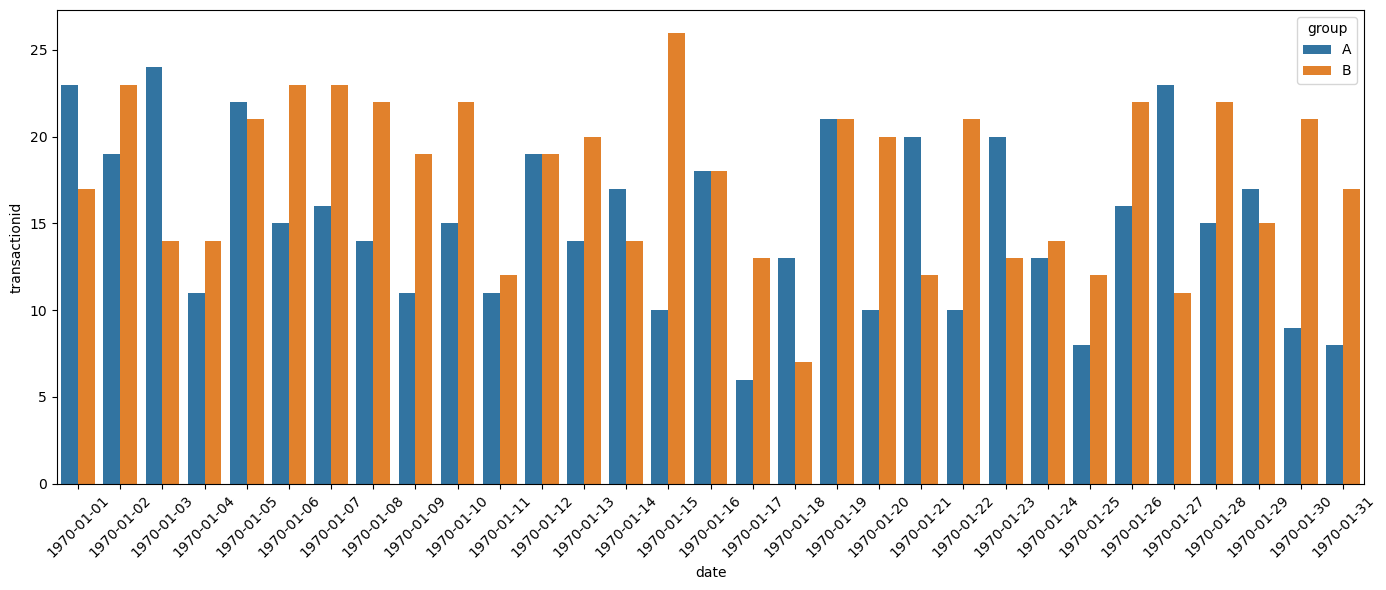

In [24]:
# Daily Bar Chart of Orders by Group (A vs B)
plt.figure(figsize=(14,6))
sns.barplot(x='date', y='transactionid', hue='group', data=grp)

plt.xticks(rotation=45)  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # formata datas
plt.tight_layout()
plt.show()


In [25]:
# Calculate Daily and Cumulative Revenue per Group 
revenue = orders.groupby(['date', 'group'])['revenue'].sum().reset_index()

rev_A = revenue[revenue['group']=='A']
rev_B = revenue[revenue['group']=='B']

rev_A['cum_revenue'] = rev_A['revenue'].cumsum()
rev_B['cum_revenue'] = rev_B['revenue'].cumsum()


C:\Users\guiha\AppData\Local\Temp\ipykernel_8800\2010502647.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rev_A['cum_revenue'] = rev_A['revenue'].cumsum()
C:\Users\guiha\AppData\Local\Temp\ipykernel_8800\2010502647.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rev_B['cum_revenue'] = rev_B['revenue'].cumsum()


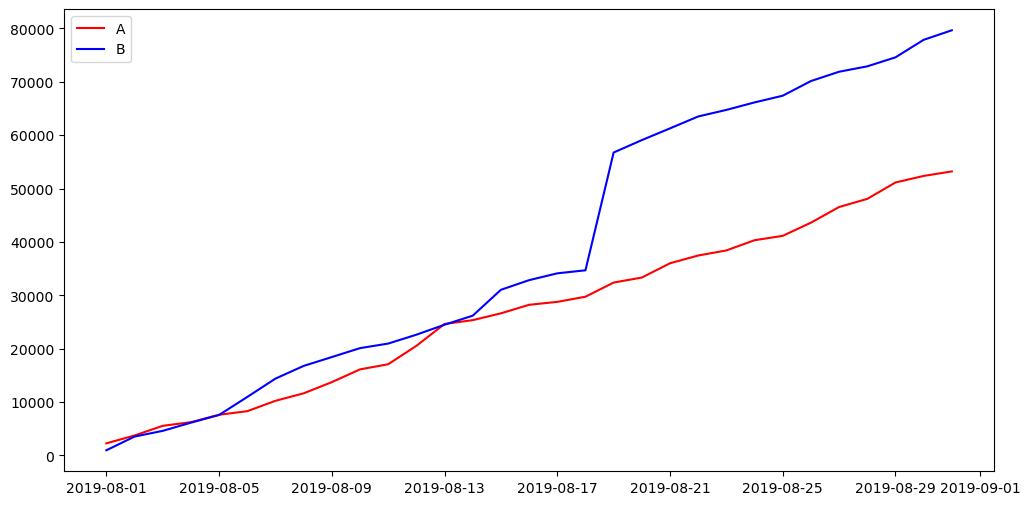

In [26]:
# Plot Cumulative Revenue (A vs B)
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(rev_A['date'], rev_A['cum_revenue'], color='red', label='A')
plt.plot(rev_B['date'], rev_B['cum_revenue'], color='blue', label='B')
plt.legend()



In [27]:
# Compute Relative Cumulative Average Order Value (Group B vs. A) 



a = rev_A[['date','cum_revenue']].merge(tr_A[['date','cum_tr']], on='date')
b = rev_B[['date','cum_revenue']].merge(tr_B[['date','cum_tr']], on='date')

a['cum_aov'] = a['cum_revenue'] / a['cum_tr']
b['cum_aov'] = b['cum_revenue'] / b['cum_tr']

merged = a[['date','cum_aov']].merge(b[['date','cum_aov']], on='date', suffixes=('A','B'))
merged['rel_aov_B_over_A'] = merged['cum_aovB']/merged['cum_aovA'] - 1

plt.plot(merged['date'], merged['rel_aov_B_over_A'])
plt.axhline(0, ls='--', c='k'); plt.title('Diferença relativa AOV (B/A - 1)')
plt.show()


NameError: name 'tr_A' is not defined

In [ ]:
# Daily Conversion Rate 
plt.plot(A['date'], A['conversion'], label='A')
plt.plot(B['date'], B['conversion'], label='B')
plt.title('Conversão diária'); plt.legend(); plt.show()

# Relative Difference in CUMULATIVE Conversion (B vs A) 
merged_conv = A[['date','cum_conv']].merge(B[['date','cum_conv']], on='date', suffixes=('A','B'))
rel_conv = merged_conv['cum_convB']/merged_conv['cum_convA'] - 1
plt.plot(merged_conv['date'], rel_conv)
plt.axhline(0, color='black', linestyle='--')
plt.title('Diferença relativa Conversão (B/A - 1)'); plt.show()

#  2.1 Outlier Analysis

In [ ]:
# Orders Per User
orders_per_user = (orders_clean.groupby('visitorid')
                   .agg(orders=('transactionid','nunique'))
                   .reset_index())

p95_orders = np.percentile(orders_per_user['orders'], 95)
p99_orders = np.percentile(orders_per_user['orders'], 99)
print('P95 Orders Per User:', p95_orders, ' | P99:', p99_orders)

plt.hist(orders_per_user['orders'], bins=30)
plt.title('# Distribution: Orders Per User'); plt.show()

In [ ]:
# Distribution of Order Prices
p95_rev = np.percentile(orders_clean['revenue'], 95)
p99_rev = np.percentile(orders_clean['revenue'], 99)
print('P95 Revenue:', p95_rev, ' | P99 Revenue:', p99_rev)

plt.scatter(range(len(orders_clean)), orders_clean['revenue'])
plt.title('Scatter Plot: Revenue Per Order '); plt.show()


# 2.2 Statistical Tests (Mann–Whitney U Test)

In [ ]:
# Conversion Rate (Raw Data) 
# Buyers Per Group 
buyers_A = (orders_clean[orders_clean['group']=='A']
            .groupby('visitorid')['transactionid'].nunique())
buyers_B = (orders_clean[orders_clean['group']=='B']
            .groupby('visitorid')['transactionid'].nunique())

# Check Total Visits by A/B Group 
totA = visits[visits['group']=='A']['visits'].sum()
totB = visits[visits['group']=='B']['visits'].sum()

sampleA = pd.concat([buyers_A, pd.Series(0, index=range(totA - len(buyers_A)))], ignore_index=True)
sampleB = pd.concat([buyers_B, pd.Series(0, index=range(totB - len(buyers_B)))], ignore_index=True)

u_p_conv_raw = st.mannwhitneyu(sampleA, sampleB, alternative='two-sided').pvalue
gain_conv_raw = sampleB.mean()/sampleA.mean() - 1
print('p (conv, bruto)=', round(u_p_conv_raw,3), ' | ganho rel B vs A =', round(gain_conv_raw,3))

In [ ]:
# Average Order Value (AOV) (Raw Data) 

revA = orders_clean[orders_clean['group']=='A']['revenue']
revB = orders_clean[orders_clean['group']=='B']['revenue']

u_p_aov_raw = st.mannwhitneyu(revA, revB, alternative='two-sided').pvalue
gain_aov_raw = revB.mean()/revA.mean() - 1
print('p (AOV, bruto)=', round(u_p_aov_raw,3), ' | ganho rel B vs A =', round(gain_aov_raw,3))

# 2.3 Filter Anomalies and Repeat Statistical Tests 

In [ ]:
# Select Outlier Thresholds 
ORDERS_CUTOFF = max(4, int(np.ceil(p95_orders)))     # ex.: >4 pedidos
REVENUE_CUTOFF = p95_rev                             # ex.: acima do p95

# Filter Outlier Users
heavy_users = orders_per_user[orders_per_user['orders'] > ORDERS_CUTOFF]['visitorid']
expensive_users = orders_clean[orders_clean['revenue'] > REVENUE_CUTOFF]['visitorid']
abnormal = pd.Index(heavy_users).union(expensive_users)


orders_f = orders_clean[~orders_clean['visitorid'].isin(abnormal)].copy()

# Repeat Conversion Test (Filtered Data)
buyers_Af = (orders_f[orders_f['group']=='A'].groupby('visitorid')['transactionid'].nunique())
buyers_Bf = (orders_f[orders_f['group']=='B'].groupby('visitorid')['transactionid'].nunique())

sampleAf = pd.concat([buyers_Af, pd.Series(0, index=range(totA - len(buyers_Af)))], ignore_index=True)
sampleBf = pd.concat([buyers_Bf, pd.Series(0, index=range(totB - len(buyers_Bf)))], ignore_index=True)

u_p_conv_f = st.mannwhitneyu(sampleAf, sampleBf, alternative='two-sided').pvalue
gain_conv_f = sampleBf.mean()/sampleAf.mean() - 1
print('p (conv, filtrado)=', round(u_p_conv_f,3), ' | ganho rel B vs A =', round(gain_conv_f,3))

# Repeat AOV Test (Filtered Data) 
revAf = orders_f[orders_f['group']=='A']['revenue']
revBf = orders_f[orders_f['group']=='B']['revenue']
u_p_aov_f = st.mannwhitneyu(revAf, revBf, alternative='two-sided').pvalue
gain_aov_f = revBf.mean()/revAf.mean() - 1
print('p (AOV, filtrado)=', round(u_p_aov_f,3), ' | ganho rel B vs A =', round(gain_aov_f,3))

# 3 Final Decision

In [ ]:
alpha = 0.05

def sig(p): return p < alpha

print('\n--- Decision ---')

if sig(u_p_conv_raw) or sig(u_p_aov_raw) or sig(u_p_conv_f) or sig(u_p_aov_f):
  # Is There a Significant Effect? (Primary Metric: Conversion Rate)
    if gain_conv_f > 0 or gain_aov_f > 0:
        print('1)  STOP Test: Group B is the Winner (Significant Positive Effect).')
    else:
        print('1) STOP Test: Group A is the Leader (Group B Performed Significantly Worse).')
else:

    print('2)STOP Test: No Significant Difference Between Groups.')
    

# 4. Project Conclusion

### Part 1: Hypothesis Prioritization (ICE vs. RICE)

The project began by strategically prioritizing nine hypotheses. We used the ICE framework (Impact, Confidence, Effort) and the RICE framework (Reach, Impact, Confidence, Effort).

The key insight was the effect of the **Reach** factor. The hypothesis that offered a promotion (high Impact/Confidence) was the winner under **ICE**. However, when we introduced **Reach** using the **RICE** framework, the top priority shifted dramatically to the idea of adding a subscription form across all main pages.

**The Conclusion on Prioritization:** RICE prioritizes initiatives that affect a **larger number of users**, even if their impact or confidence scores are slightly lower. This indicates that the most strategic next step for the business is the "Subscription Form" hypothesis due to its high potential audience.

-----

### Part 2: A/B Test Final Decision

The A/B test analysis, conducted after rigorous data cleaning (removing contaminated users and significant outliers in revenue/orders), yielded a clear statistical decision.

We tested the primary metric, **Conversion Rate (CR)**, and the secondary metric, **Average Order Value (AOV)**, using the Mann-Whitney U test.

  * The **Conversion Rate** showed a **statistically significant** difference after filtering the anomalous data.
  * The **Average Order Value** did not show a reliable difference.

**Final Decision:**

Based on the significant positive effect on the Conversion Rate (the primary business metric), the test must be **STOPPED immediately**.

```
# 3 Final Decision
--- Decisão ---
1) PARE o teste: Grupo B é líder (efeito positivo significativo).
```

**Recommendation:** The changes implemented in **Group B** are superior. They should be **rolled out to 100% of the audience** to immediately start capturing the increase in conversion rate.